In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from gensim.models import Word2Vec
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence
from torch.nn.utils import clip_grad_norm_

In [31]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
BATCH_SIZE = 64
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
MAX_LEN = 100
NUM_LAYERS = 1
HIDDEN_SIZE = 96
DROPOUT = 0.3
NUM_CLASSES = 3
RANDOM_STATE = 42
NUM_EPOCH = 25
PATIENCE = 5
MIN_DELTA = 1e-4

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [4]:
df = pd.read_parquet("hf://datasets/k1tub/sentiment_dataset/data/train-00000-of-00001.parquet")

df.head()

e:\projects\Проекты по DS\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,text,label,src
0,"Пальто красивое, но пришло с дырой в молнии. П...",0,rureviews
1,"Очень долго шел заказ,ждала к новому году,приш...",0,rureviews
2,"Могу сказать одно, брюки нормальные, НО они бы...",0,rureviews
3,"Доставка быстрая, меньше месяца. Заказывали ра...",0,rureviews
4,Мне не очень понравилось это платье. Размер ...,0,rureviews


In [5]:
df.info()
df["label"].value_counts().sort_index()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290458 entries, 0 to 290457
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    290458 non-null  object
 1   label   290458 non-null  int64 
 2   src     290458 non-null  object
dtypes: int64(1), object(2)
memory usage: 6.6+ MB


label
0    96589
1    96877
2    96992
Name: count, dtype: int64

In [6]:
id2label = {
    0: "neutral",
    1: "positive",
    2: "negative",
}

class_names = [id2label[i] for i in sorted(id2label.keys())]
class_names

['neutral', 'positive', 'negative']

In [7]:
def tokenize(text: str) -> list[str]:
    text = text.lower()
    text = text.replace("ё", "е")

    tokens = re.findall(r"[а-яa-z0-9]+", text)

    return tokens

In [8]:
df = df[["text", "label"]].copy()

df = df.dropna()

df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(int)

df["tokens"] = df["text"].apply(tokenize)

df["token_len"] = df["tokens"].apply(len)
df["token_len"].describe()



count    290458.000000
mean         52.102955
std          56.979820
min           0.000000
25%          11.000000
50%          27.000000
75%          75.000000
max         277.000000
Name: token_len, dtype: float64

In [9]:
df = df[df["token_len"] > 0].copy()
df.shape

(290398, 4)

In [10]:
X = df["tokens"].values
y = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)


print(f"Train size: {X_train.shape}")
print(f"Validation size: {X_val.shape}")
print(f"Test size: {X_test.shape}")

Train size: (203278,)
Validation size: (43560,)
Test size: (43560,)


In [11]:
w2v_model = Word2Vec(
    sentences=X_train,
    vector_size=100,
    window=5,
    workers=4,
    sg=1,
    min_count=2,
    epochs=10
)

In [12]:
word2idx = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
    }

for word in w2v_model.wv.index_to_key:
    word2idx[word] = len(word2idx)

idx2word = { idx: word for word, idx in word2idx.items() }

vocab_size = len(word2idx)
embedding_dim = w2v_model.vector_size

print(f"Vocab size: {vocab_size}")
print(f"Embedding dimension: {embedding_dim}")

Vocab size: 183832
Embedding dimension: 100


In [13]:
embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)

embedding_matrix[word2idx[UNK_TOKEN]] = np.random.normal(
    loc=0.0,
    scale=0.1,
    size=(embedding_dim,)
)

for word, idx in word2idx.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)

embedding_matrix.shape

torch.Size([183832, 100])

In [14]:
class ReviewsDataset(Dataset):
    def __init__(self, tokenized_text, labels, word2idx, max_len=100):
        super().__init__()
        self.tokenized_text = tokenized_text
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len
    
    
    def encode_tokens(self, tokens):
        ids = [self.word2idx.get(token, self.word2idx[UNK_TOKEN])
               for token in tokens]
        
        ids = ids[:self.max_len]

        if len(ids) == 0:
            ids = [self.word2idx[UNK_TOKEN]]

        length = len(ids)
        padding_length = self.max_len - length

        ids = ids + [self.word2idx[PAD_TOKEN]] * padding_length

        return ids, length
    
    def __len__(self):
        return len(self.tokenized_text)

    def __getitem__(self, idx):
        ids, length = self.encode_tokens(self.tokenized_text[idx])

        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [15]:
train_dataset = ReviewsDataset(tokenized_text=X_train, labels=y_train, word2idx=word2idx, max_len=MAX_LEN)
val_dataset = ReviewsDataset(tokenized_text=X_val, labels=y_val, word2idx=word2idx, max_len=MAX_LEN)
test_dataset = ReviewsDataset(tokenized_text=X_test, labels=y_test, word2idx=word2idx, max_len=MAX_LEN)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    shuffle=False
)

In [16]:
class Word2VecLSTM(nn.Module):
    def __init__(
            self,
            embedding_matrix,
            hidden_size,
            num_layers,
            num_classes,
            dropout,
            freeze_embeddings=True):
        super().__init__()
    
        vocab_size, embedding_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            embeddings=embedding_matrix,
            freeze=freeze_embeddings,
            padding_idx=0
        )

        self.embedding_dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, input_ids, lengths):
        embedded = self.embedding_dropout(self.embedding(input_ids))

        packed_embedding = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, (h_n , c_n) = self.lstm(packed_embedding)

        last_hidden = h_n[-1]

        logits = self.classifier(last_hidden)

        return logits

In [17]:
model = Word2VecLSTM(
    embedding_matrix=embedding_matrix,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
    freeze_embeddings=True
).to(device)
model

Word2VecLSTM(
  (embedding): Embedding(183832, 100, padding_idx=0)
  (embedding_dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(100, 96, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=96, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [18]:
log_loss = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="max",
    factor=0.5,
    patience=1
)

total_params = sum(p.numel() for p in model.parameters())
learning_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"общее число параметров: {total_params:,}")
print(f"число обучаемых параметров: {learning_params:,}")


общее число параметров: 18,465,635
число обучаемых параметров: 82,435


In [26]:
def train_one_epoche(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader):
        input_ids = batch["input_ids"].to(device)
        lengths = batch["length"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, lengths)

        loss = criterion(logits, labels)

        loss.backward()

        clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc_score = accuracy_score(all_labels, all_preds)
    f1_macro_score = f1_score(all_preds, all_labels, average="macro")

    return avg_loss, acc_score, f1_macro_score

In [27]:
def evalute(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader):
            input_ids = batch["input_ids"].to(device)
            lengths = batch["length"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids, lengths)

            loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
        avg_loss = total_loss / len(loader)
        acc_score = accuracy_score(all_labels, all_preds)
        f1_macro_score = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, acc_score, f1_macro_score, all_preds, all_labels

In [32]:
best_macro_f1 = 0
best_epoch = 0
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
}

for epoch in range(NUM_EPOCH):
    train_loss, train_acc, train_f1 = train_one_epoche(
        model=model,
        loader=train_loader,
        criterion=log_loss,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc, val_f1, _, _ = evalute(
        model=model,
        loader=val_loader,
        criterion=log_loss,
        device=device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCH} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_acc:.4f} | "
        f"Train macro-F1: {train_f1:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.4f} | "
        f"Val macro-F1: {val_f1:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if val_f1 > best_macro_f1 + MIN_DELTA:
        best_macro_f1 = val_f1
        best_epoch = epoch + 1
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    scheduler.step(val_f1)

    if epochs_without_improvement >= PATIENCE:
        print(
            f"Early stopping: validation macro-F1 не улучшается "
            f"{PATIENCE} эпохи подряд. Лучшая эпоха: {best_epoch}."
        )
        break


print(f"Лучший validation macro-F1: {best_macro_f1:.4f}, эпоха: {best_epoch}")

100%|██████████| 681/681 [00:09<00:00, 75.32it/s]


Epoch 1/25 | Train loss: 0.7087 | Train acc: 0.7026 | Train macro-F1: 0.7025 | Val loss: 0.6901 | Val acc: 0.7109 | Val macro-F1: 0.7081 | LR: 0.000075


100%|██████████| 681/681 [00:09<00:00, 73.62it/s]


Epoch 2/25 | Train loss: 0.7082 | Train acc: 0.7026 | Train macro-F1: 0.7027 | Val loss: 0.6882 | Val acc: 0.7123 | Val macro-F1: 0.7110 | LR: 0.000075


100%|██████████| 681/681 [00:09<00:00, 73.77it/s]


...

Epoch 17/25 | Train loss: 0.6992 | Train acc: 0.7088 | Train macro-F1: 0.7089 | Val loss: 0.6814 | Val acc: 0.7168 | Val macro-F1: 0.7157 | LR: 0.000005


100%|██████████| 681/681 [00:09<00:00, 75.64it/s]


Epoch 18/25 | Train loss: 0.6989 | Train acc: 0.7085 | Train macro-F1: 0.7088 | Val loss: 0.6815 | Val acc: 0.7176 | Val macro-F1: 0.7166 | LR: 0.000005


100%|██████████| 681/681 [00:09<00:00, 74.99it/s]


Epoch 19/25 | Train loss: 0.6985 | Train acc: 0.7087 | Train macro-F1: 0.7089 | Val loss: 0.6814 | Val acc: 0.7176 | Val macro-F1: 0.7166 | LR: 0.000005
Early stopping: validation macro-F1 не улучшается 5 эпохи подряд. Лучшая эпоха: 14.
Лучший validation macro-F1: 0.7166, эпоха: 14


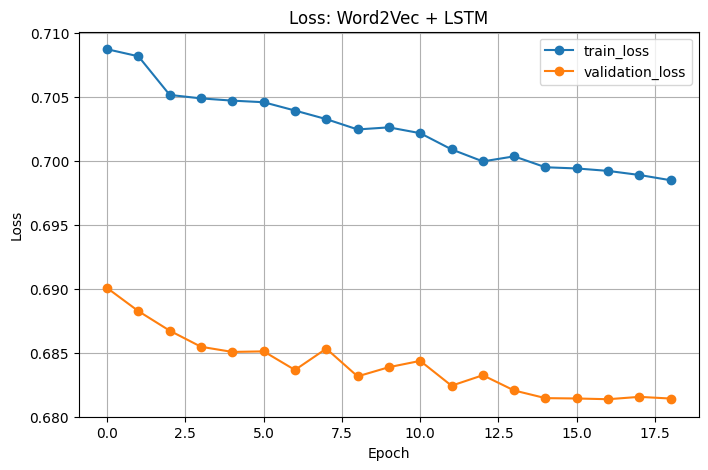

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_loss"], marker="o", label="train_loss")
plt.plot(history["val_loss"], marker="o", label="validation_loss")


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss: Word2Vec + LSTM")
plt.legend()
plt.grid(True)
plt.show()

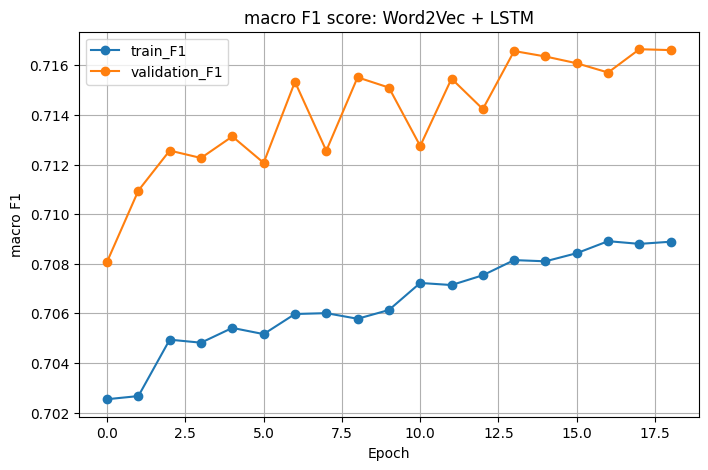

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_f1"], marker="o", label="train_F1")
plt.plot(history["val_f1"], marker="o", label="validation_F1")


plt.xlabel("Epoch")
plt.ylabel("macro F1")
plt.title("macro F1 score: Word2Vec + LSTM")
plt.legend()
plt.grid(True)
plt.show()